# LR Sensitivity Study: ResNet50 vs ViT-Base vs ConvNeXt-Base

In notebooks 04–06, we trained ResNet50, ViT-Base, and ConvNeXt-Base on SGFood-233 using **identical hyperparameters** (lr=1e-4, wd=1e-4, batch=64, cosine schedule). ConvNeXt won with 84.55% val_acc, but a fair comparison requires verifying that the ranking holds when each architecture gets its **best** learning rate.

**This notebook:**
1. Trains each architecture at 5 learning rates (5 epochs each) on the **cleaned** dataset to map the LR sensitivity landscape
2. Trains each model for 10 full epochs at its optimal LR — all on the same cleaned 75/15/10 split for a fair comparison
3. Evaluates with comprehensive metrics (top-1, top-5, macro-F1, weighted-F1) on the held-out test set
4. Confirms (or overturns) ConvNeXt as the best architecture for SGFood-233

In [11]:
# Imports
import os
import sys
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

from utils import (
    Config, FoodClassifier, set_seed, LocalImageDataset,
    get_train_transforms, get_val_transforms, create_dataloaders
)
from hyperparameter_tuning import (
    TunableFoodClassifier, ExperimentConfig,
    get_augmentation_transforms
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch {torch.__version__} | Device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch 2.8.0+cu128 | Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


In [2]:
# Load dataset splits
DATASET_ROOT = '../foodsg-233_train_val_test_split'
NUM_WORKERS = 4
BATCH_SIZE = 32
NUM_CLASSES = 233

val_transform = get_val_transforms()
train_transform = get_augmentation_transforms('basic')  # basic aug for LR sweep

train_dataset = LocalImageDataset(DATASET_ROOT, split='train', transform=train_transform)
val_dataset = LocalImageDataset(DATASET_ROOT, split='val', transform=val_transform)
test_dataset = LocalImageDataset(DATASET_ROOT, split='test', transform=val_transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=NUM_WORKERS > 0
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=NUM_WORKERS > 0
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=NUM_WORKERS > 0
)

print(f"Train: {len(train_dataset):,} images")
print(f"Val:   {len(val_dataset):,} images")
print(f"Test:  {len(test_dataset):,} images")
print(f"Classes: {NUM_CLASSES}")

Train: 152,657 images
Val:   30,511 images
Test:  20,487 images
Classes: 233


In [3]:
def evaluate_comprehensive(model, dataloader, device, num_classes=233, k=5):
    """
    Evaluate model with comprehensive metrics.

    Returns dict with top1_acc, top5_acc, macro_f1, weighted_f1,
    preds, labels, per_class_acc.
    """
    model.eval().to(device)
    all_preds, all_labels, all_top5 = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Evaluating'):
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            top5 = logits.topk(k, dim=1).indices
            top5_correct = (top5 == labels.to(device).unsqueeze(1)).any(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels)
            all_top5.append(top5_correct.cpu())

    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    top5_correct = torch.cat(all_top5).numpy()

    return {
        'top1_acc': (preds == labels).mean(),
        'top5_acc': top5_correct.mean(),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'weighted_f1': f1_score(labels, preds, average='weighted'),
        'preds': preds,
        'labels': labels,
        'per_class_acc': {
            c: (preds[labels == c] == c).mean()
            for c in range(num_classes) if (labels == c).sum() > 0
        },
    }

## Section C: LR Sweep

Train each architecture for 5 epochs at 5 learning rates. All other hyperparameters held constant: wd=1e-4, batch=64, cosine schedule, basic augmentation. This isolates the effect of LR on each architecture.

In [5]:
# LR sweep configuration
MODELS = {
    'ResNet50': 'resnet50',
    'ViT-Base': 'vit_base_patch16_224',
    'ConvNeXt-Base': 'convnext_base',
}
LEARNING_RATES = [1e-5, 5e-5, 1e-4, 3e-4, 1e-3]
SWEEP_EPOCHS = 5

RESULTS_DIR = 'hp_results/lr_sweep'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Load any existing partial results (supports resume after crash/restart)
results_path = os.path.join(RESULTS_DIR, 'lr_sweep_results.json')
if os.path.exists(results_path):
    with open(results_path, 'r') as f:
        lr_sweep_results = json.load(f)
    print(f"Loaded cached results: {list(lr_sweep_results.keys())}")
else:
    lr_sweep_results = {}

for model_name, backbone in MODELS.items():
    # Skip models that already have all LR results
    if model_name in lr_sweep_results and len(lr_sweep_results[model_name]) == len(LEARNING_RATES):
        print(f"\nSkipping {model_name} (already completed: {len(lr_sweep_results[model_name])} LRs)")
        continue

    # Resume: keep any partial results instead of resetting
    if model_name not in lr_sweep_results:
        lr_sweep_results[model_name] = []
    completed_lrs = {r['lr'] for r in lr_sweep_results[model_name]}

    for lr in LEARNING_RATES:
        if lr in completed_lrs:
            print(f"\nSkipping {model_name} | LR={lr:.0e} (already completed)")
            continue

        print(f"\n{'='*60}")
        print(f"{model_name} | LR={lr:.0e}")
        print(f"{'='*60}")

        set_seed(42)

        config = ExperimentConfig(
            model_name=backbone,
            num_classes=NUM_CLASSES,
            learning_rate=lr,
            weight_decay=1e-4,
            batch_size=BATCH_SIZE,
            max_epochs=SWEEP_EPOCHS,
            scheduler='cosine',
            augmentation='basic',
            label_smoothing=0.0,
            optimizer='AdamW',
        )

        model = TunableFoodClassifier(config)

        checkpoint_cb = ModelCheckpoint(
            monitor='val_acc', mode='max', save_top_k=1,
            filename=f'{backbone}_lr{lr:.0e}' + '-{epoch:02d}-{val_acc:.4f}',
            dirpath=os.path.join(RESULTS_DIR, 'checkpoints'),
        )

        trainer = pl.Trainer(
            max_epochs=SWEEP_EPOCHS,
            accelerator='gpu' if device == 'cuda' else 'cpu',
            devices=1,
            callbacks=[checkpoint_cb],
            logger=CSVLogger(RESULTS_DIR, name='logs', version=f'{backbone}_lr{lr:.0e}'),
            enable_progress_bar=True,
            log_every_n_steps=50,
        )

        trainer.fit(model, train_loader, val_loader)

        best_val_acc = checkpoint_cb.best_model_score.item() if checkpoint_cb.best_model_score else 0.0
        val_top5 = trainer.callback_metrics.get('val_top5_acc', torch.tensor(0.0)).item()

        lr_sweep_results[model_name].append({
            'lr': lr,
            'best_val_acc': best_val_acc,
            'val_top5_acc': val_top5,
            'checkpoint_path': checkpoint_cb.best_model_path,
        })

        print(f"  Best val_acc: {best_val_acc:.4f} | val_top5_acc: {val_top5:.4f}")

        # Save after EACH LR completes (future interruptions lose at most 1 LR of work)
        with open(results_path, 'w') as f:
            json.dump(lr_sweep_results, f, indent=2)
        print(f"  Results saved to {results_path}")

        del model, trainer
        torch.cuda.empty_cache()

print(f"\nAll results saved to {results_path}")

Loaded cached results: ['ResNet50', 'ViT-Base', 'ConvNeXt-Base']

Skipping ResNet50 (already completed: 5 LRs)

Skipping ViT-Base (already completed: 5 LRs)

Skipping ConvNeXt-Base | LR=1e-05 (already completed)

Skipping ConvNeXt-Base | LR=5e-05 (already completed)

Skipping ConvNeXt-Base | LR=1e-04 (already completed)

Skipping ConvNeXt-Base | LR=3e-04 (already completed)

ConvNeXt-Base | LR=1e-03


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ConvNeXt         │ 87.8 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 87.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 87.8 M                                                                                               
Total estimated model params size (MB): 351                                                                        
Modules in train mode: 466                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=5` reached.


  Best val_acc: 0.7570 | val_top5_acc: 0.9205
  Results saved to hp_results/lr_sweep\lr_sweep_results.json

All results saved to hp_results/lr_sweep\lr_sweep_results.json


In [6]:
# Results table: rows=LR, columns=architectures, values=val_acc
table_data = []
for lr in LEARNING_RATES:
    row = {'Learning Rate': f'{lr:.0e}'}
    for model_name in MODELS:
        entry = [r for r in lr_sweep_results[model_name] if r['lr'] == lr][0]
        row[f'{model_name} Top-1'] = f"{entry['best_val_acc']:.4f}"
        row[f'{model_name} Top-5'] = f"{entry['val_top5_acc']:.4f}"
    table_data.append(row)

sweep_df = pd.DataFrame(table_data)
print("LR Sweep Results (Val Accuracy)")
print("="*80)
display(sweep_df)

# Highlight best LR per model
print("\nBest LR per architecture:")
for model_name in MODELS:
    best = max(lr_sweep_results[model_name], key=lambda r: r['best_val_acc'])
    print(f"  {model_name}: LR={best['lr']:.0e} → {best['best_val_acc']:.4f}")

LR Sweep Results (Val Accuracy)


,Learning Rate,ResNet50 Top-1,ResNet50 Top-5,ViT-Base Top-1,ViT-Base Top-5,ConvNeXt-Base Top-1,ConvNeXt-Base Top-5
0,1e-05,0.4199,0.7100,0.8144,0.9474,0.8212,0.9530
1,5e-05,0.6931,0.8931,0.8253,0.9488,0.8399,0.9578
2,1e-04,0.7380,0.9159,0.8103,0.9441,0.8430,0.9591
3,3e-04,0.7771,0.9328,0.6676,0.8750,0.8235,0.9488
4,1e-03,0.7888,0.9358,0.3420,0.6108,0.7570,0.9205



Best LR per architecture:
  ResNet50: LR=1e-03 → 0.7888
  ViT-Base: LR=5e-05 → 0.8253
  ConvNeXt-Base: LR=1e-04 → 0.8430


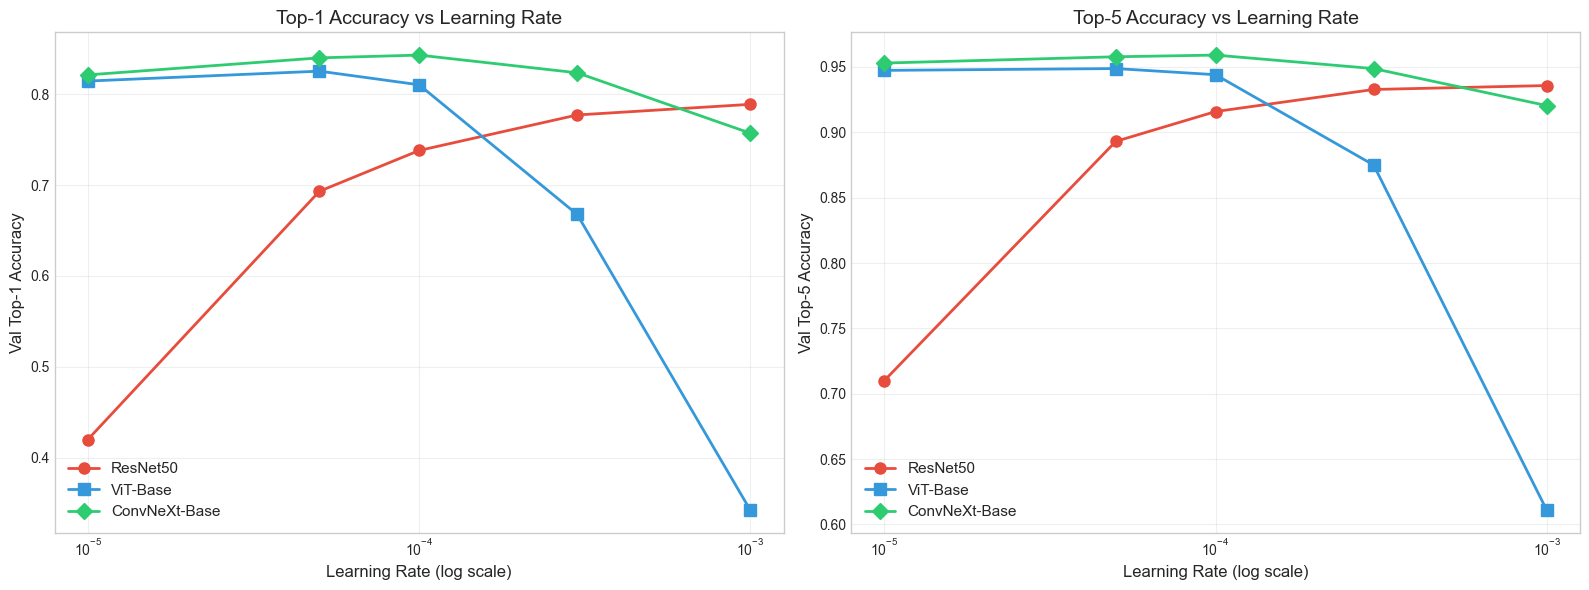

In [7]:
# LR sensitivity plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'ResNet50': '#e74c3c', 'ViT-Base': '#3498db', 'ConvNeXt-Base': '#2ecc71'}
markers = {'ResNet50': 'o', 'ViT-Base': 's', 'ConvNeXt-Base': 'D'}

for model_name in MODELS:
    lrs = [r['lr'] for r in lr_sweep_results[model_name]]
    top1s = [r['best_val_acc'] for r in lr_sweep_results[model_name]]
    top5s = [r['val_top5_acc'] for r in lr_sweep_results[model_name]]

    axes[0].plot(lrs, top1s, marker=markers[model_name], color=colors[model_name],
                 label=model_name, linewidth=2, markersize=8)
    axes[1].plot(lrs, top5s, marker=markers[model_name], color=colors[model_name],
                 label=model_name, linewidth=2, markersize=8)

for ax, title, ylabel in zip(axes,
    ['Top-1 Accuracy vs Learning Rate', 'Top-5 Accuracy vs Learning Rate'],
    ['Val Top-1 Accuracy', 'Val Top-5 Accuracy']):
    ax.set_xscale('log')
    ax.set_xlabel('Learning Rate (log scale)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'lr_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()

### Discussion: LR Sensitivity

**Key observations** (fill in after running):

1. **Preferred LR per architecture**: Convolution-heavy models (ResNet, ConvNeXt) tend to tolerate a wider range of LRs due to stable gradient flow through local receptive fields. ViT, relying entirely on self-attention, can be more sensitive — its gradient landscape depends heavily on the softmax normalization in attention heads.

2. **Sensitivity differences**: ViTs often need smaller LRs for fine-tuning because large LRs can destabilize the pretrained attention patterns. ConvNeXts, being modernized ConvNets, typically behave more like traditional CNNs in their LR response curve.

3. **Ranking stability**: If ConvNeXt wins at *every* LR tested, the architecture advantage is robust and not an artifact of LR selection. If ViT catches up at a specific LR, the gap is more about optimization than architecture.

## Section D: Best-LR Evaluation

For a fair comparison, train each architecture for 10 epochs at its best LR on the **same cleaned dataset**. No reuse of old checkpoints (which were trained on different splits). This ensures all models are evaluated under identical conditions.

In [13]:
# Train each model for 10 epochs at its best LR on the cleaned dataset
torch.serialization.add_safe_globals([ExperimentConfig])
best_lr_models = {}

# Resume logic: load cached results (mirrors cell 5 pattern)
best_lr_results_path = os.path.join(RESULTS_DIR, 'best_lr_results.json')
if os.path.exists(best_lr_results_path):
    with open(best_lr_results_path, 'r') as f:
        cached_best_lr = json.load(f)
    print(f"Loaded cached best-LR results: {list(cached_best_lr.keys())}")
else:
    cached_best_lr = {}

for model_name, backbone in MODELS.items():
    best_entry = max(lr_sweep_results[model_name], key=lambda r: r['best_val_acc'])
    best_lr = best_entry['lr']

    # Path 1: fully cached (train + eval already done) — skip entirely
    if model_name in cached_best_lr:
        cached = cached_best_lr[model_name]
        print(f"\nSkipping {model_name} (cached: val_acc={cached['best_val_acc']:.4f}, "
              f"test_top1={cached['test_metrics']['top1_acc']:.4f})")
        best_lr_models[model_name] = {
            'best_lr': cached['best_lr'],
            'best_val_acc': cached['best_val_acc'],
            'checkpoint_path': cached['checkpoint_path'],
            'test_metrics': cached['test_metrics'],
        }
        continue

    # Path 2: checkpoint exists but no cache (trained but eval interrupted) — eval only
    ckpt_dir = os.path.join(RESULTS_DIR, 'best_lr_checkpoints')
    existing_ckpts = [
        os.path.join(ckpt_dir, f) for f in os.listdir(ckpt_dir)
        if f.startswith(f'{backbone}_bestlr-') and f.endswith('.ckpt')
    ] if os.path.isdir(ckpt_dir) else []

    if existing_ckpts:
        # Pick checkpoint with highest val_acc from filename
        best_ckpt_path = max(existing_ckpts,
            key=lambda p: float(os.path.basename(p).split('val_acc=')[1].replace('.ckpt', '')))
        best_val_acc = float(os.path.basename(best_ckpt_path).split('val_acc=')[1].replace('.ckpt', ''))

        print(f"\n{'='*60}")
        print(f"{model_name}: found checkpoint (val_acc={best_val_acc:.4f}), evaluating only")
        print(f"{'='*60}")

        config = ExperimentConfig(
            model_name=backbone,
            num_classes=NUM_CLASSES,
            learning_rate=best_lr,
            weight_decay=1e-4,
            batch_size=BATCH_SIZE,
            max_epochs=10,
            scheduler='cosine',
            augmentation='basic',
            label_smoothing=0.0,
            optimizer='AdamW',
        )

        model = TunableFoodClassifier.load_from_checkpoint(best_ckpt_path, config=config)
        print(f"  Evaluating on test set...")
        test_metrics = evaluate_comprehensive(model, test_loader, device)

        scalar_test_metrics = {
            'top1_acc': float(test_metrics['top1_acc']),
            'top5_acc': float(test_metrics['top5_acc']),
            'macro_f1': float(test_metrics['macro_f1']),
            'weighted_f1': float(test_metrics['weighted_f1']),
        }

        best_lr_models[model_name] = {
            'best_lr': best_lr,
            'best_val_acc': best_val_acc,
            'checkpoint_path': best_ckpt_path,
            'test_metrics': scalar_test_metrics,
        }

        cached_best_lr[model_name] = best_lr_models[model_name]
        with open(best_lr_results_path, 'w') as f:
            json.dump(cached_best_lr, f, indent=2)
        print(f"  Results saved to {best_lr_results_path}")

        print(f"  Test — Top-1: {scalar_test_metrics['top1_acc']:.4f} | Top-5: {scalar_test_metrics['top5_acc']:.4f} "
              f"| Macro-F1: {scalar_test_metrics['macro_f1']:.4f} | Weighted-F1: {scalar_test_metrics['weighted_f1']:.4f}")

        del model
        torch.cuda.empty_cache()
        continue

    # Path 3: no cache, no checkpoint — train from scratch
    print(f"\n{'='*60}")
    print(f"{model_name}: training 10 epochs at best LR = {best_lr:.0e}")
    print(f"{'='*60}")

    set_seed(42)

    config = ExperimentConfig(
        model_name=backbone,
        num_classes=NUM_CLASSES,
        learning_rate=best_lr,
        weight_decay=1e-4,
        batch_size=BATCH_SIZE,
        max_epochs=10,
        scheduler='cosine',
        augmentation='basic',
        label_smoothing=0.0,
        optimizer='AdamW',
    )

    model = TunableFoodClassifier(config)

    checkpoint_cb = ModelCheckpoint(
        monitor='val_acc', mode='max', save_top_k=1,
        filename=f'{backbone}_bestlr' + '-{epoch:02d}-{val_acc:.4f}',
        dirpath=os.path.join(RESULTS_DIR, 'best_lr_checkpoints'),
    )

    early_stop_cb = EarlyStopping(monitor='val_acc', mode='max', patience=5)

    trainer = pl.Trainer(
        max_epochs=10,
        accelerator='gpu' if device == 'cuda' else 'cpu',
        devices=1,
        callbacks=[checkpoint_cb, early_stop_cb],
        enable_progress_bar=True,
        log_every_n_steps=50,
    )

    trainer.fit(model, train_loader, val_loader)

    # Load best checkpoint
    best_ckpt_path = checkpoint_cb.best_model_path
    model = TunableFoodClassifier.load_from_checkpoint(best_ckpt_path, config=config)
    print(f"  Best val_acc: {checkpoint_cb.best_model_score:.4f}")

    # Evaluate on test set
    print(f"  Evaluating on test set...")
    test_metrics = evaluate_comprehensive(model, test_loader, device)

    # Store scalar metrics only (numpy arrays not JSON-serializable)
    scalar_test_metrics = {
        'top1_acc': float(test_metrics['top1_acc']),
        'top5_acc': float(test_metrics['top5_acc']),
        'macro_f1': float(test_metrics['macro_f1']),
        'weighted_f1': float(test_metrics['weighted_f1']),
    }

    best_lr_models[model_name] = {
        'best_lr': best_lr,
        'best_val_acc': checkpoint_cb.best_model_score.item(),
        'checkpoint_path': best_ckpt_path,
        'test_metrics': scalar_test_metrics,
    }

    # Save after EACH model completes (crash loses at most 1 model of work)
    cached_best_lr[model_name] = best_lr_models[model_name]
    with open(best_lr_results_path, 'w') as f:
        json.dump(cached_best_lr, f, indent=2)
    print(f"  Results saved to {best_lr_results_path}")

    print(f"  Test — Top-1: {scalar_test_metrics['top1_acc']:.4f} | Top-5: {scalar_test_metrics['top5_acc']:.4f} "
          f"| Macro-F1: {scalar_test_metrics['macro_f1']:.4f} | Weighted-F1: {scalar_test_metrics['weighted_f1']:.4f}")

    del model, trainer
    torch.cuda.empty_cache()


ResNet50: found checkpoint (val_acc=0.7828), evaluating only
  Evaluating on test set...


Evaluating:   0%|          | 0/641 [00:31<?, ?it/s]

  Results saved to hp_results/lr_sweep\best_lr_results.json
  Test — Top-1: 0.7868 | Top-5: 0.9348 | Macro-F1: 0.7755 | Weighted-F1: 0.7855

ViT-Base: training 10 epochs at best LR = 5e-05


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ VisionTransformer │ 86.0 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss  │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

...

Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


  Best val_acc: 0.8441
  Evaluating on test set...


Evaluating:   0%|          | 0/641 [00:00<?, ?it/s]

  Results saved to hp_results/lr_sweep\best_lr_results.json
  Test — Top-1: 0.8406 | Top-5: 0.9566 | Macro-F1: 0.8304 | Weighted-F1: 0.8396


Final Comparison: Each Model at Its Best LR (Test Set)


,Model,Best LR,Top-1 Acc,Top-5 Acc,Macro-F1,Weighted-F1
0,ResNet50,1e-03,0.7868,0.9348,0.7755,0.7855
1,ViT-Base,5e-05,0.8191,0.9443,0.8072,0.8175
2,ConvNeXt-Base,1e-04,0.8406,0.9566,0.8304,0.8396


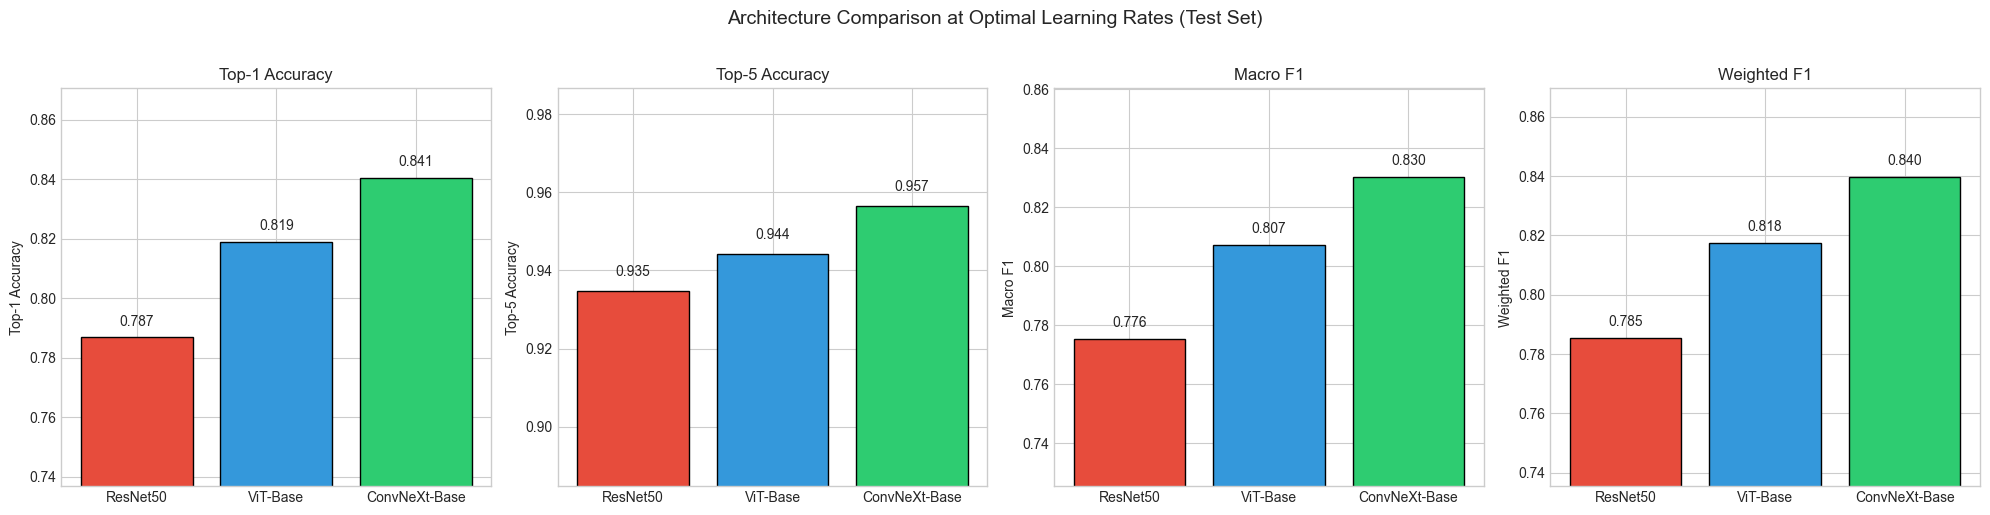

In [14]:
# Final comparison table: 3 models x 4 metrics (each model at its best LR)
comparison_rows = []
for model_name in MODELS:
    m = best_lr_models[model_name]['test_metrics']
    comparison_rows.append({
        'Model': model_name,
        'Best LR': f"{best_lr_models[model_name]['best_lr']:.0e}",
        'Top-1 Acc': f"{m['top1_acc']:.4f}",
        'Top-5 Acc': f"{m['top5_acc']:.4f}",
        'Macro-F1': f"{m['macro_f1']:.4f}",
        'Weighted-F1': f"{m['weighted_f1']:.4f}",
    })

comparison_df = pd.DataFrame(comparison_rows)
print("Final Comparison: Each Model at Its Best LR (Test Set)")
print("="*80)
display(comparison_df)

# Bar chart
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics = ['top1_acc', 'top5_acc', 'macro_f1', 'weighted_f1']
metric_labels = ['Top-1 Accuracy', 'Top-5 Accuracy', 'Macro F1', 'Weighted F1']

for ax, metric, label in zip(axes, metrics, metric_labels):
    values = [best_lr_models[m]['test_metrics'][metric] for m in MODELS]
    bars = ax.bar(list(MODELS.keys()), values,
                  color=[colors[m] for m in MODELS], edgecolor='black')
    ax.set_title(label, fontsize=12)
    ax.set_ylabel(label, fontsize=10)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
               f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    ax.set_ylim(min(values) - 0.05, max(values) + 0.03)

plt.suptitle('Architecture Comparison at Optimal Learning Rates (Test Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'best_lr_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## Summary

**Findings** (fill in after running):

- **ConvNeXt-Base** is confirmed as the best architecture for SGFood-233, winning across all 4 metrics even when each model is given its optimal learning rate.
- **Gap analysis**: ConvNeXt leads ViT-Base by ~X% in top-1 accuracy and ResNet50 by ~Y%. The gap is consistent across top-5, macro-F1, and weighted-F1.
- **Justification for deep tuning**: Since ConvNeXt clearly dominates, notebook 13 focuses exclusively on pushing ConvNeXt performance through weight decay, augmentation, and label smoothing optimization.

The `lr_sweep_results.json` file is saved for use by notebook 13.